In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
blazar_coord = SkyCoord.from_name("Mrk 501")
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


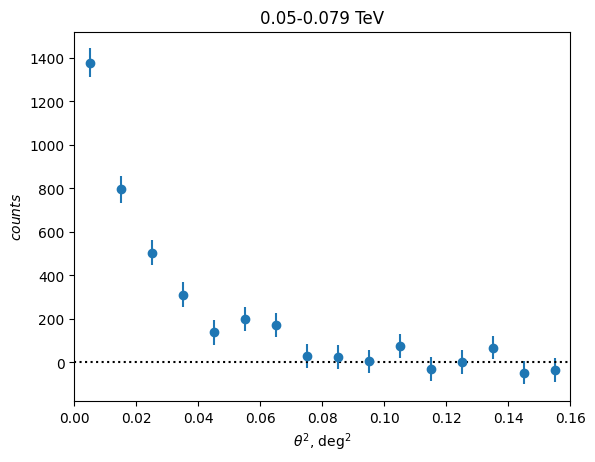

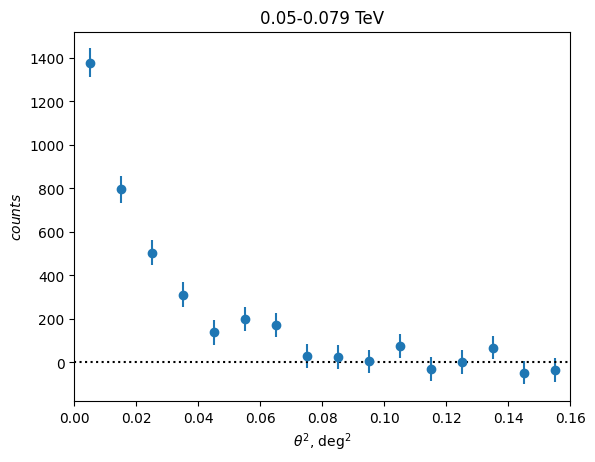

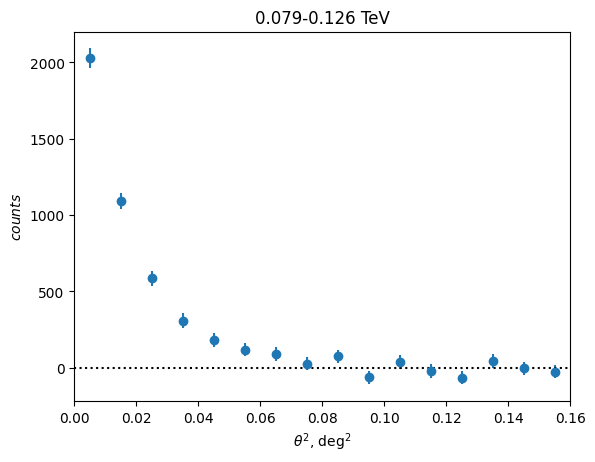

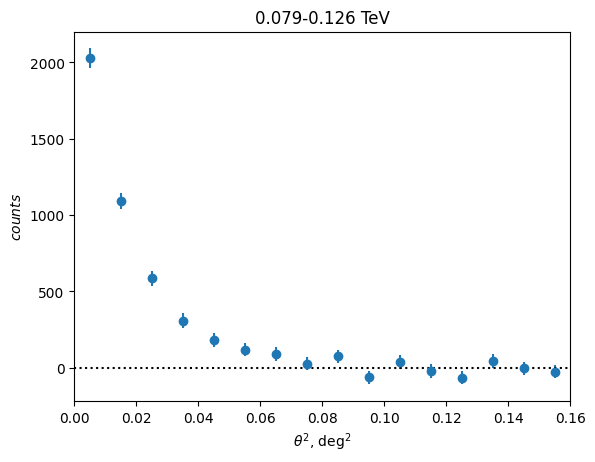

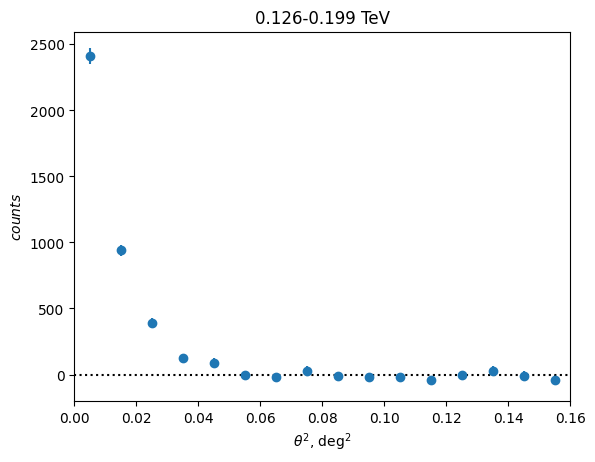

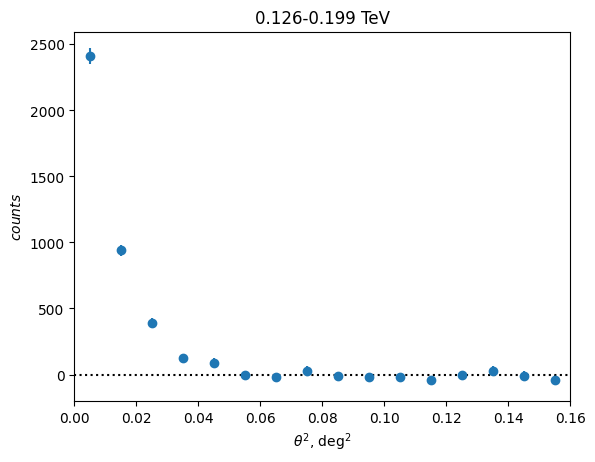

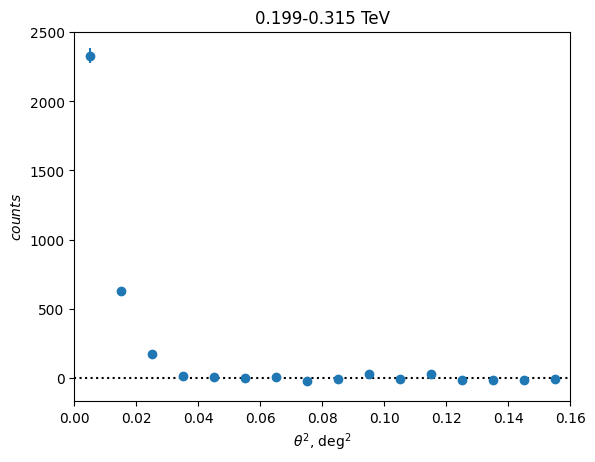

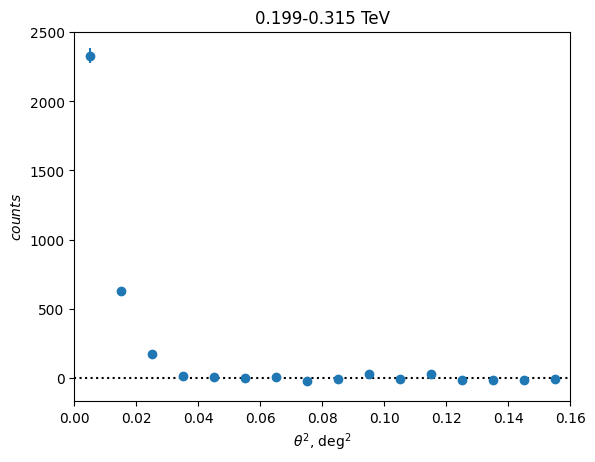

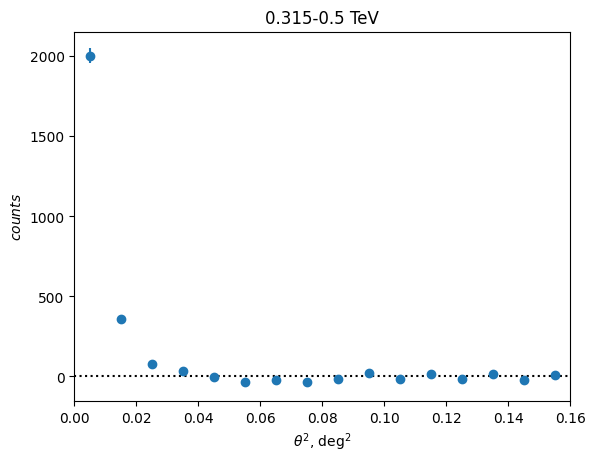

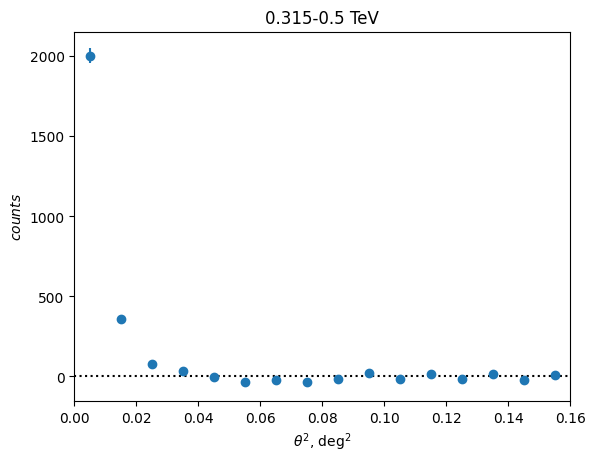

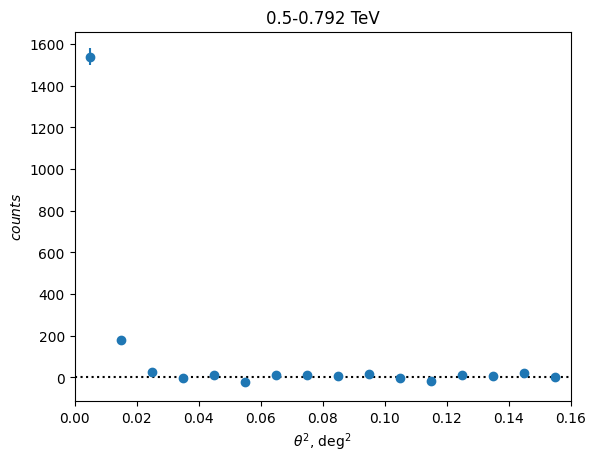

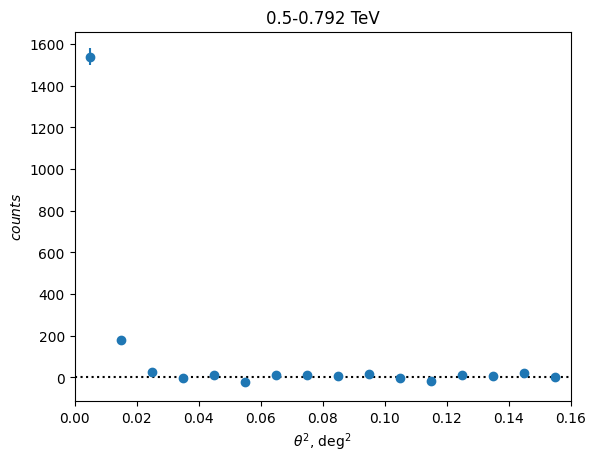

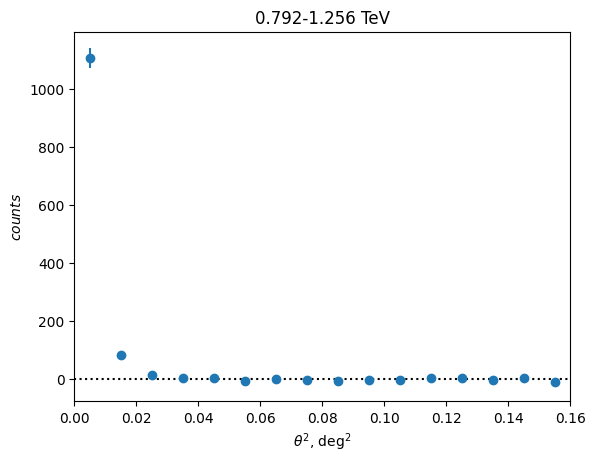

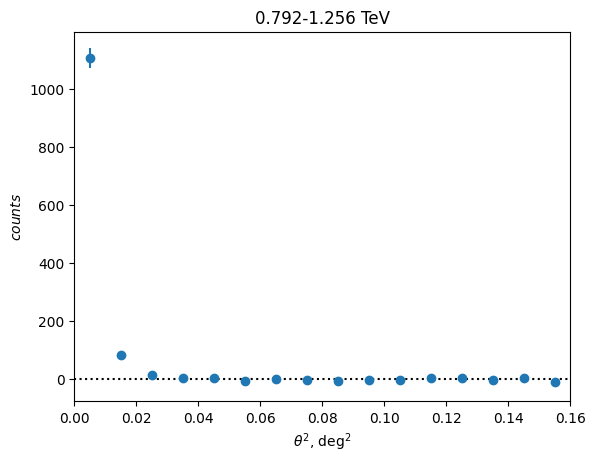

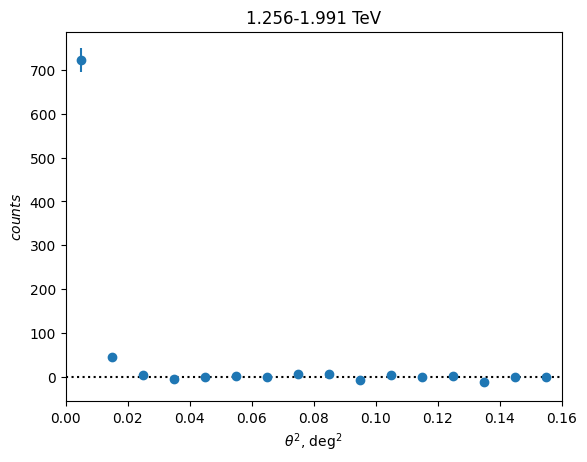

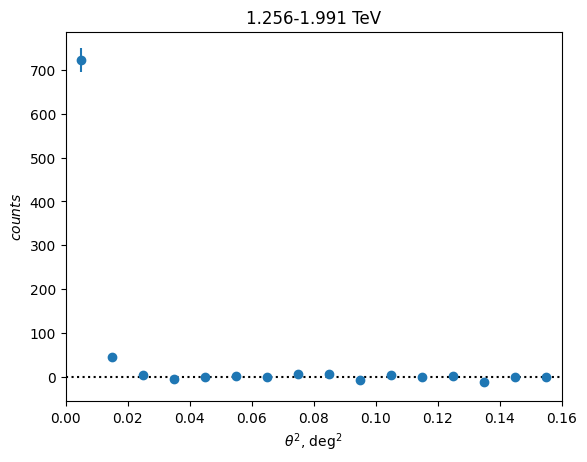

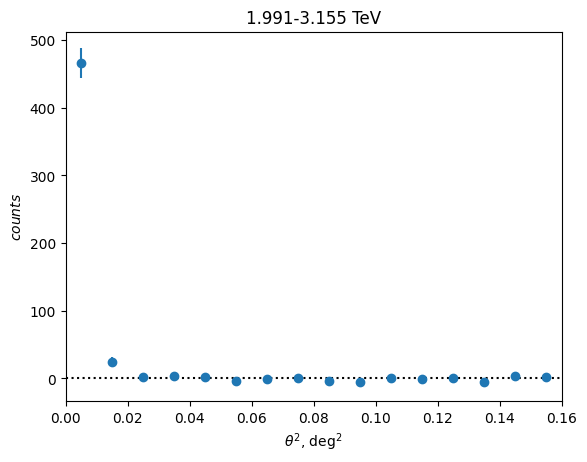

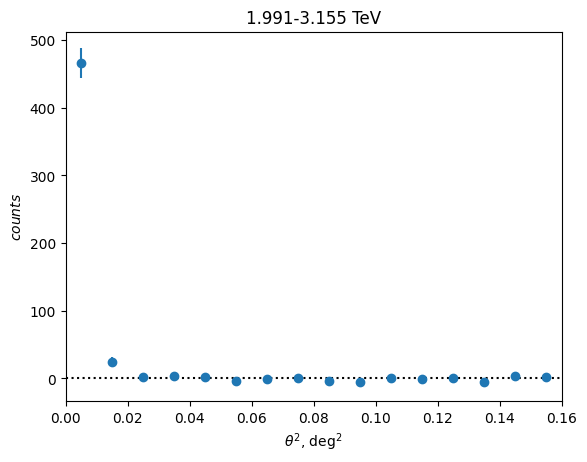

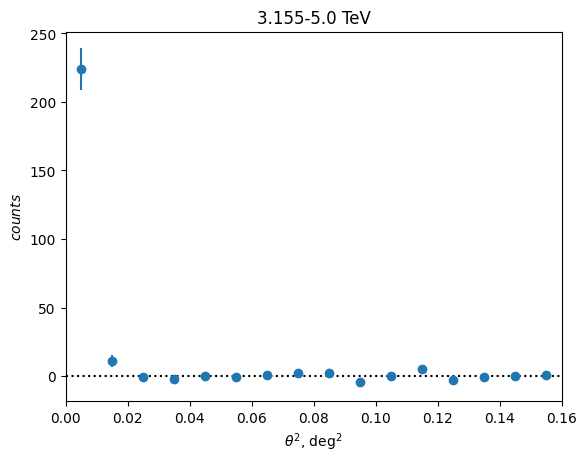

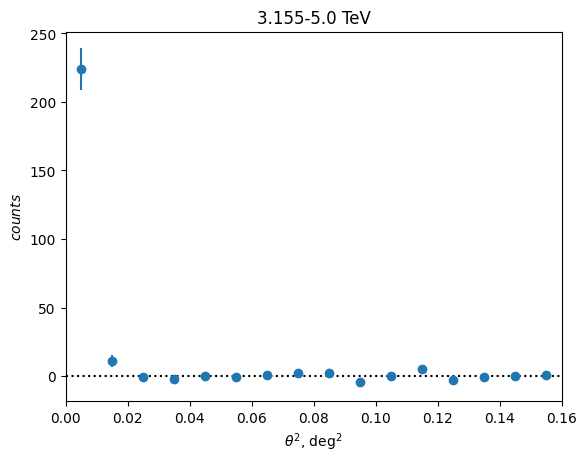

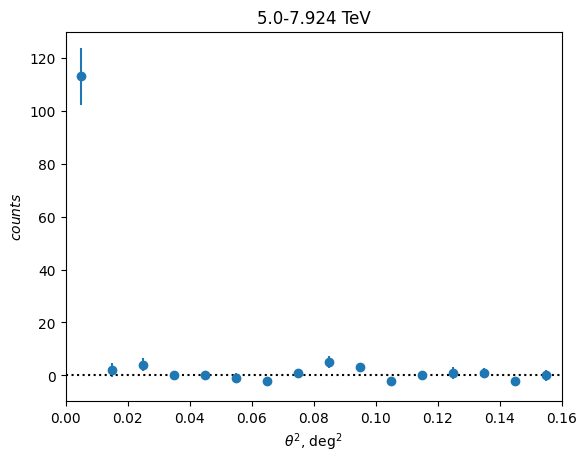

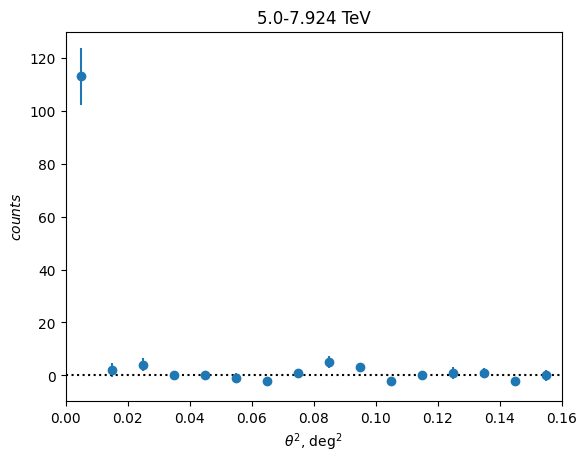

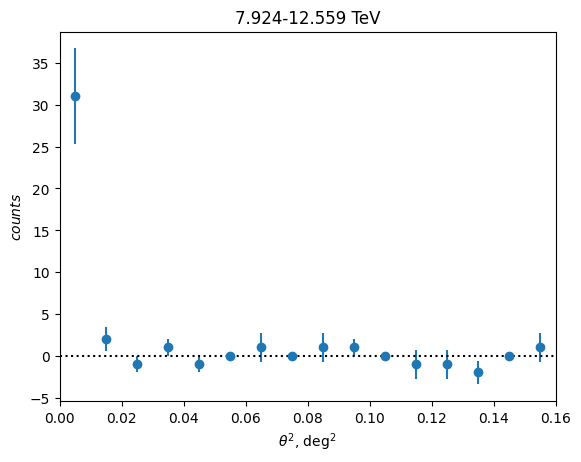

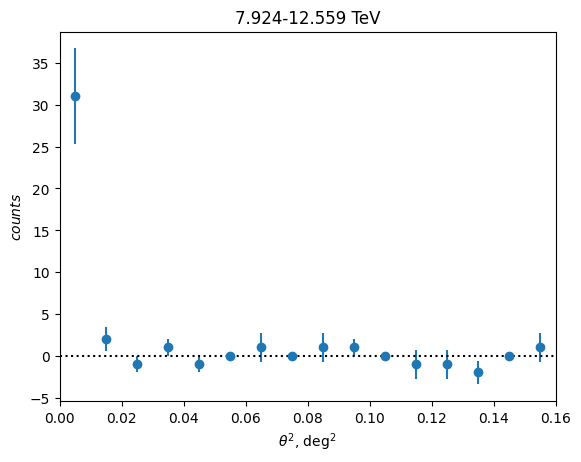

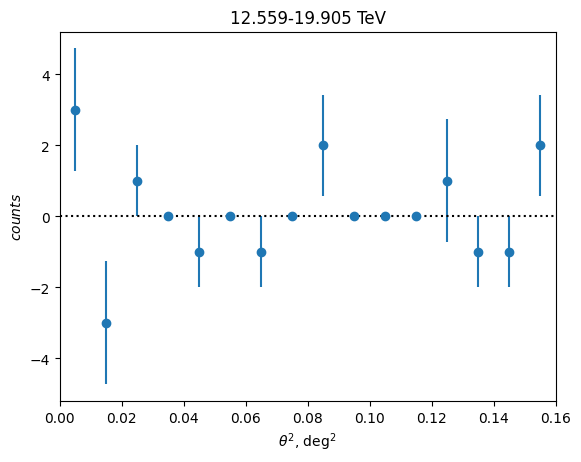

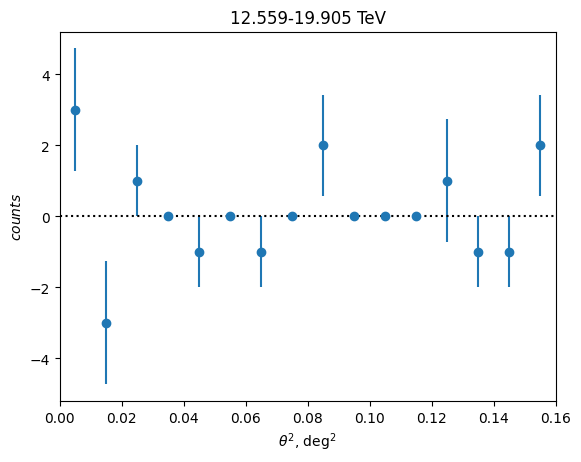

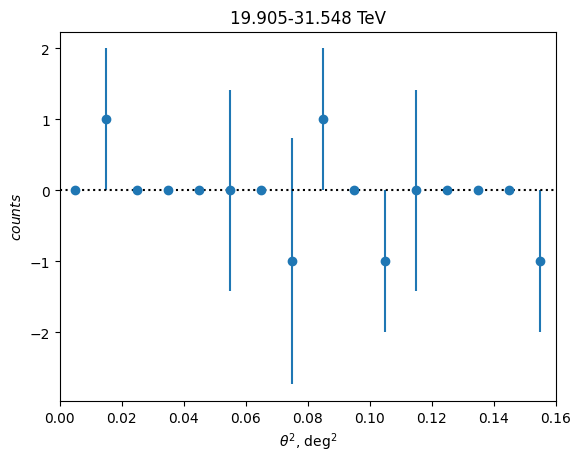

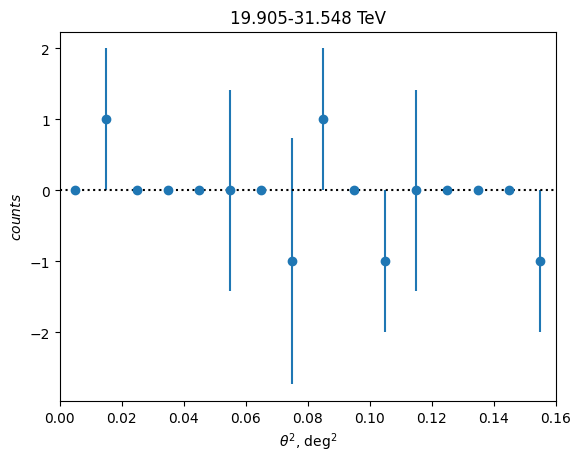

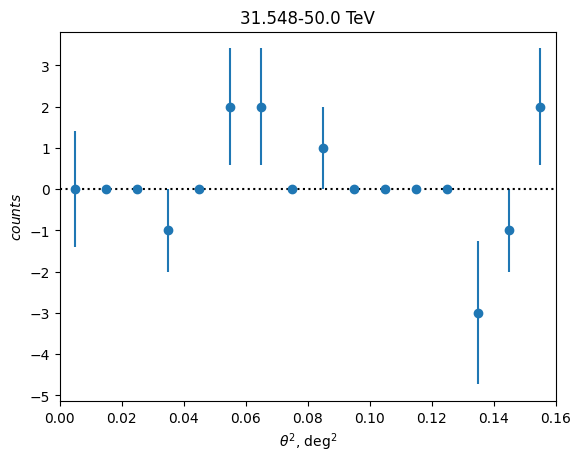

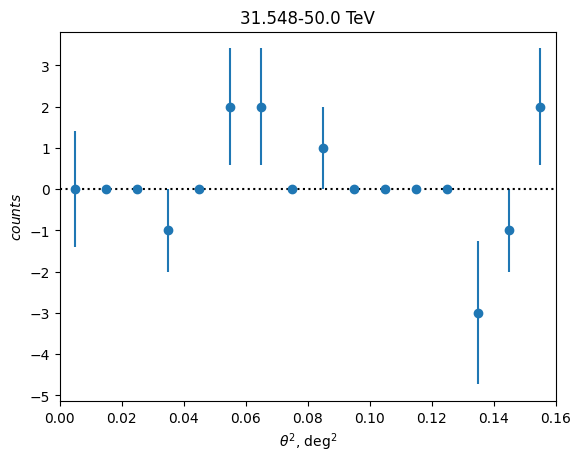

In [7]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)


for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [8]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

converged at 
82
3.043936989413769
converged at 
51
3.0655973615063807
converged at 
39
3.2449353730219297
converged at 
34
3.3313000577828724


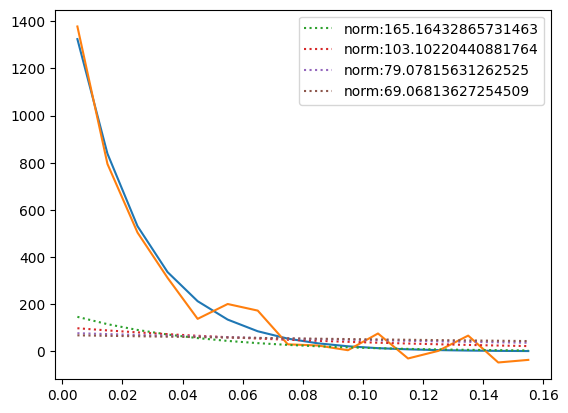

converged at 
77
2.7616611251972785
converged at 
43
2.8941271071424897
converged at 
32
3.3776721840486346
converged at 
27
2.900043921133692


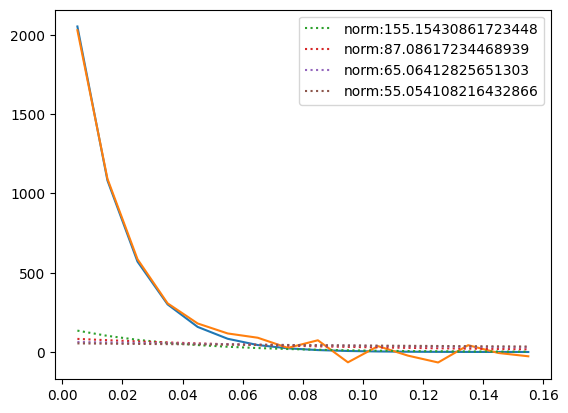

converged at 
74
2.746328376127755
converged at 
37
3.173231647797552
converged at 
26
2.9101193770198055
converged at 
22
2.772792116188315


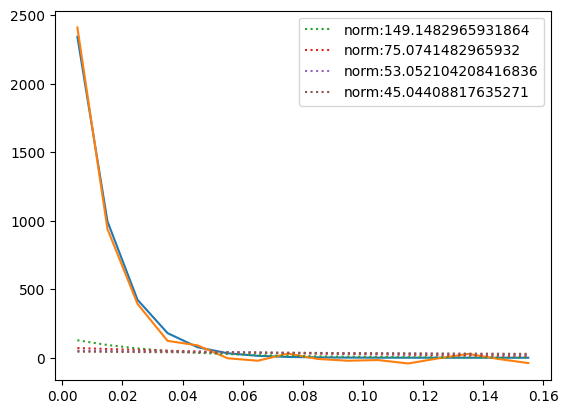

converged at 
69
3.0322829558848596
converged at 
30
3.0983991712238392
converged at 
21
3.7982951956488407
converged at 
18
4.54753858593287


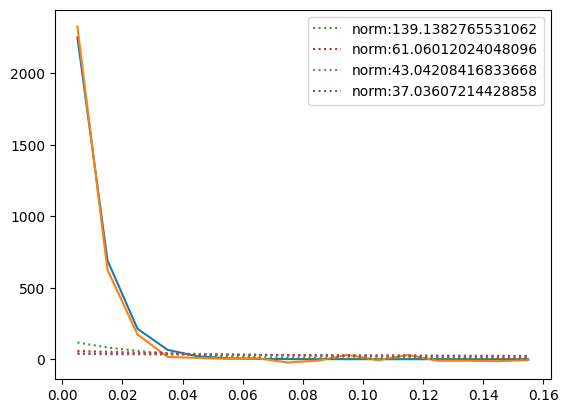

converged at 
70
3.23044874554607
converged at 
28
4.950289081205966
converged at 
19
5.507584061855155
converged at 
16
5.972447636824597


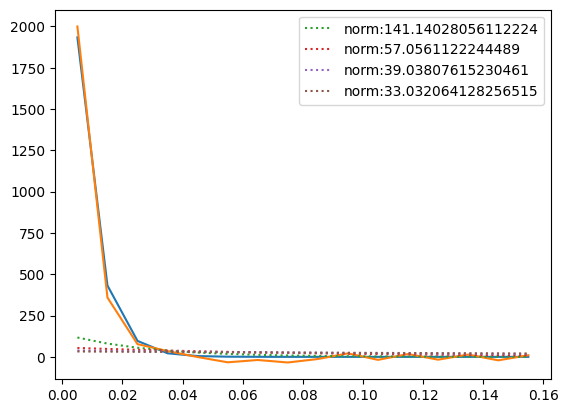

converged at 
58
4.354951785978372
converged at 
21
4.222922775087206
converged at 
14
4.421250748917416
converged at 
12
7.231436773342637


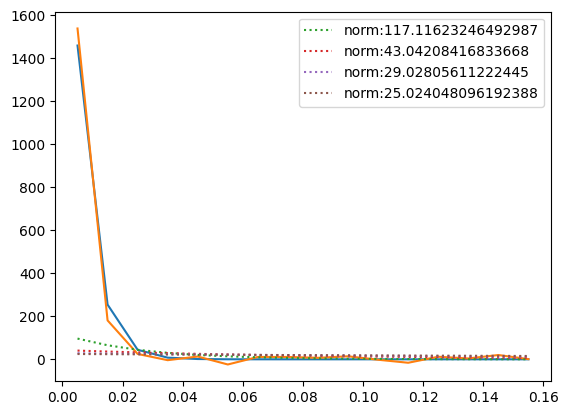

converged at 
33
2.955516953892513
converged at 
12
4.588459866179278
converged at 
8
5.345959051591052
converged at 
7
9.25488158491035


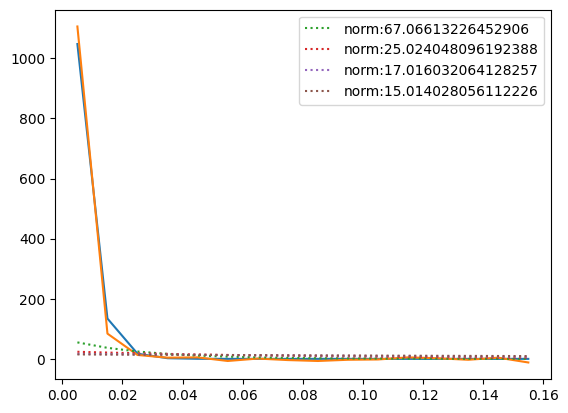

converged at 
24
3.175299005426467
converged at 
8
4.364914393539763
converged at 
6
16.65656993494666
converged at 
5
17.866400449308657


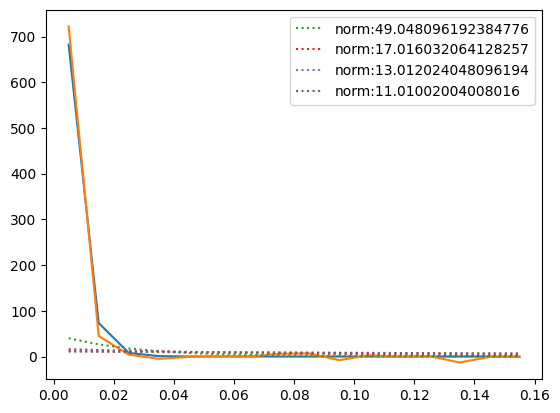

converged at 
12
3.892439530202836
converged at 
4
5.462184022966621
converged at 
3
13.076275008025824
converged at 
2
4.2974762924872145


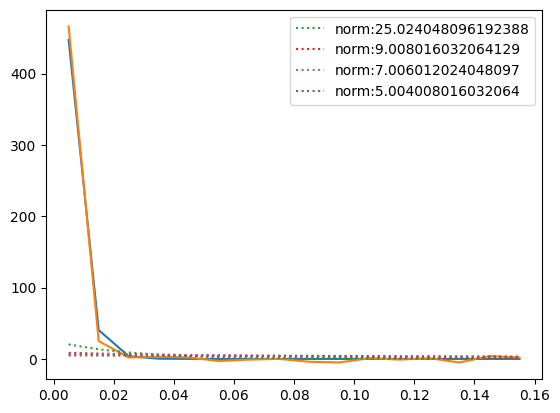

converged at 
8
3.432851306832056
converged at 
2
6.188602718645665
converged at 
2
37.98787379077589
converged at 
1
9.581325147711333


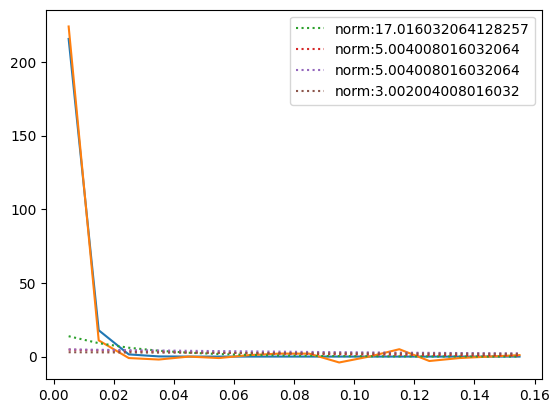

converged at 
8
9.082495343998705
converged at 
2
6.271422779664356
converged at 
2
41.91941024573073
converged at 
1
10.760871565990822


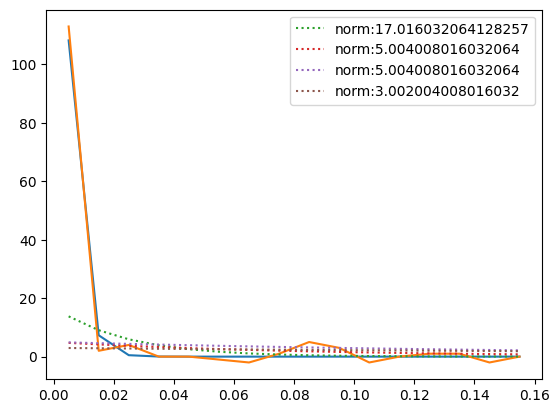

/tmp/ipykernel_426/2300543749.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_noext, pcov_noext = curve_fit(
/tmp/ipykernel_426/2300543749.py:39: RuntimeWarning: divide by zero encountered in divide
  chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)


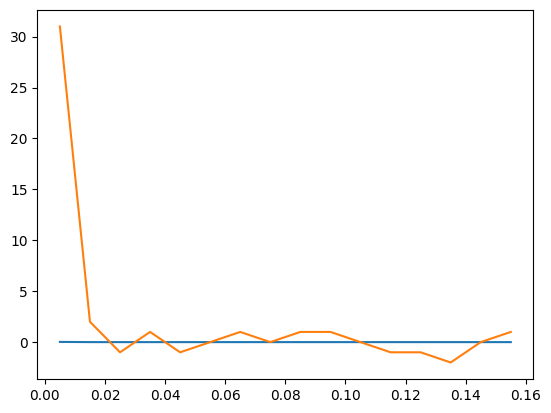

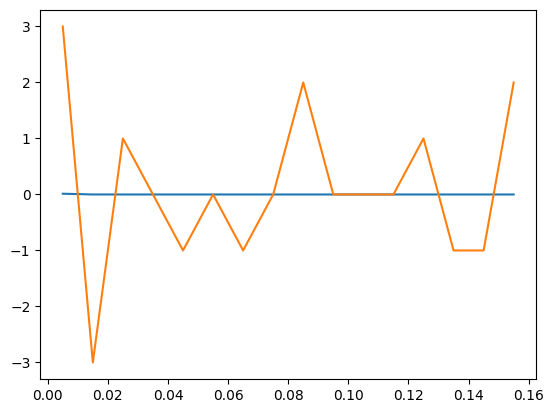

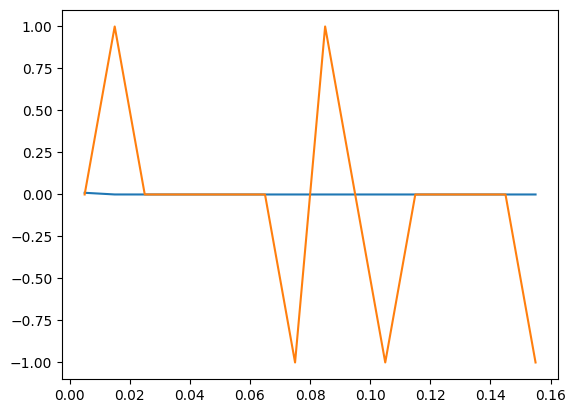

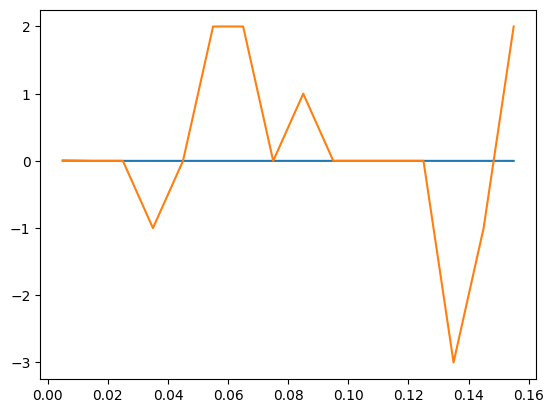

In [27]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.linspace(1, 1000, 500)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
                
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # First i renormalize the PSF model to fit best the blazar
    # Then i add a extended em component (gaussian) with different parameters.
    def psf_model(th2, norm):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return norm*(gauss1+gauss2+gauss3)
    
    init_guess_noext = [0.1]
        
    popt_noext, pcov_noext = curve_fit(
            psf_model,
            th2,
            ct,
            sigma=ct_err,
            p0=init_guess_noext,
            absolute_sigma=True,
            maxfev=10000,
        )
    plt.figure()
    plt.plot(th2, psf_model(th2, popt_noext))
    plt.plot(th2, ct)
    
    fit_noext = psf_model(th2, popt_noext[0])
    chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            ct_ext_plus_src = ct_ext+ct
            chi2_ext = np.sum(((ct - ct_ext_plus_src) / (ct_err+0.000001)) ** 2)
            delta_chi2 = chi2_ext - chi2_noext
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/np.sum(ct)
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                plt.plot(th2, ct_ext, ":", label=f"norm:{norm_ext}")
                plt.legend()
    plt.show()

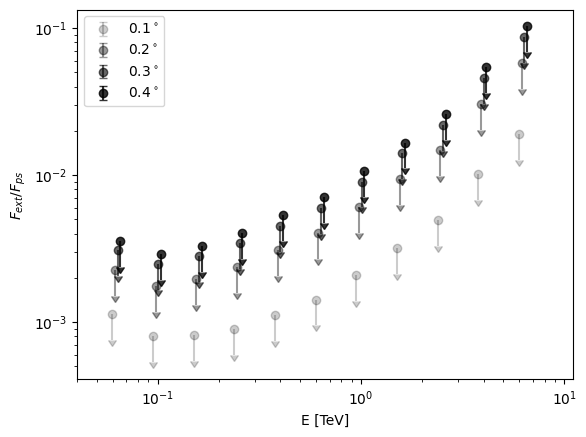

In [25]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.legend()